In [ ]:
from ultralytics import YOLO
from pathlib import Path

BEST = Path("/kaggle/working/runs_face_mask/yolo_s/weights/best.pt")  
m = YOLO(BEST.as_posix())
print("Names:", m.names)       
print("Model type:", m.task)    
print("NC:", m.model.model[-1].nc if hasattr(m.model, 'model') else 'unknown')


Names: {0: 'with_mask', 1: 'without_mask', 2: 'mask_weared_incorrect'}
Model type: detect
NC: 3


In [ ]:
import cv2, numpy as np
img_path = "/kaggle/working/data/face_mask_dn/images/test/maksssksksss103.png"  
im = cv2.imread(img_path)
r = m.predict(source=im, imgsz=960, conf=0.10, iou=0.6, verbose=True)[0]
print("Boxes:", r.boxes)       
print("Scores:", r.boxes.conf.cpu().numpy() if r.boxes is not None else None)
print("Classes:", r.boxes.cls.cpu().numpy() if r.boxes is not None else None)



0: 736x960 (no detections), 26.1ms
Speed: 3.8ms preprocess, 26.1ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 960)
Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (300, 400)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))
Scores: []
Classes: []


In [33]:
import glob, os
for p in glob.glob("/kaggle/working/runs_face_mask/**/weights/*.pt", recursive=True):
    print(p, os.path.getsize(p))


/kaggle/working/runs_face_mask/yolo_s/weights/last.pt 67236246
/kaggle/working/runs_face_mask/yolo_s/weights/best.pt 67236246
/kaggle/working/runs_face_mask/yolo_s2/weights/last.pt 22520163
/kaggle/working/runs_face_mask/yolo_s2/weights/best.pt 22520163


In [ ]:
ok = m.export(format="onnx", dynamic=False, opset=12)
print("Exported:", ok)

m2 = YOLO(BEST.as_posix())


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs_face_mask/yolo_s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (64.1 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.18.0 opset 12...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success ✅ 7.6s, saved as '/kaggle/working/runs_face_mask/yolo_s/weights/best.onnx' (42.7 MB)

Export complete (8.2s)
Results saved to /kaggle/working/runs_face_mask/yolo_s/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs_face_mask/yolo_

In [ ]:

base = YOLO("yolov8n.pt")
r = base.predict(source=im, imgsz=640, conf=0.25, verbose=False)[0]
print("Base boxes:", len(r.boxes))


Base boxes: 5


In [36]:
import cv2, random
from pathlib import Path

ROOT = Path("/kaggle/working/data/face_mask_dn")
lbls = sorted((ROOT/"labels/train").glob("*.txt"))
imgs = ROOT/"images/train"

def show_one(lblp):
    stem = lblp.stem
    ip = imgs/(stem + ".png")
    if not ip.exists(): 
        ip = imgs/(stem + ".jpg")
    im = cv2.imread(str(ip))
    H,W = im.shape[:2]
    ok=False
    for line in open(lblp):
        cls, cx, cy, w, h = map(float, line.strip().split())
        # denorm
        x1 = int((cx - w/2) * W); y1 = int((cy - h/2) * H)
        x2 = int((cx + w/2) * W); y2 = int((cy + h/2) * H)
        if x2>x1 and y2>y1:
            ok=True
            cv2.rectangle(im,(x1,y1),(x2,y2),(0,255,0),2)
    return im, ok, ip.name

for p in random.sample(lbls, 5):
    im, ok, name = show_one(p)
    print(name, "valid_boxes=", ok)


maksssksksss166.png valid_boxes= True
maksssksksss359.png valid_boxes= True
maksssksksss686.png valid_boxes= True
maksssksksss707.png valid_boxes= True
maksssksksss508.png valid_boxes= True


In [ ]:
# Install and imports
!pip -q install ultralytics>=8.2.0 opencv-python pillow

import os, sys, json, random, shutil, glob
from pathlib import Path
import numpy as np, cv2
from PIL import Image
from ultralytics import YOLO

random.seed(42)
ROOT = Path("/kaggle/working")  
print("ROOT:", ROOT)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnxslim 0.1.70 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.
ROOT: /kaggle/working


In [ ]:

DN_DIR = Path("/kaggle/input/facemaskdetect/ds")  
IMG_SRC = DN_DIR / "img"
ANN_SRC = DN_DIR / "ann"

print("IMG_SRC exists:", IMG_SRC.exists(), "count:", len(list(IMG_SRC.glob("*.*"))))
print("ANN_SRC exists:", ANN_SRC.exists(), "count:", len(list(ANN_SRC.glob("*.json"))))
assert IMG_SRC.exists() and ANN_SRC.exists(), "DatasetNinja ds/img or ds/ann not found"


IMG_SRC exists: True count: 853
ANN_SRC exists: True count: 853


In [ ]:

OUT = ROOT / "data" / "face_mask_dn"
for p in [OUT, OUT/"images"/"train", OUT/"images"/"val", OUT/"images"/"test",
          OUT/"labels"/"train", OUT/"labels"/"val", OUT/"labels"/"test"]:
    p.mkdir(parents=True, exist_ok=True)

classes = ["with_mask","without_mask","mask_weared_incorrect"]
cls2id = {c:i for i,c in enumerate(classes)}

def im_size(p):
    with Image.open(p) as im:
        return im.size  # W,H

def clamp_box(x1,y1,x2,y2,W,H):
    x1=max(0,min(W-1,int(round(x1)))); y1=max(0,min(H-1,int(round(y1))))
    x2=max(0,min(W-1,int(round(x2)))); y2=max(0,min(H-1,int(round(y2))))
    if x2<=x1 or y2<=y1: return None
    return x1,y1,x2,y2

def to_yolo(x1,y1,x2,y2,W,H,cid):
    x1,y1,x2,y2 = map(float,(x1,y1,x2,y2))
    W=float(W); H=float(H)
    w = x2-x1; h=y2-y1
    cx=(x1+x2)/2.0; cy=(y1+y2)/2.0
    return f"{cid} {cx/W:.6f} {cy/H:.6f} {w/W:.6f} {h/H:.6f}"

def norm_ann_stem(p:Path):
    s = p.stem.lower()        
    for ext in (".png",".jpg",".jpeg"):
        if s.endswith(ext):   # -> 
            return s[:-len(ext)]
    return s

# Build maps
img_list = sorted(list(IMG_SRC.glob("*.png")) + list(IMG_SRC.glob("*.jpg")) + list(IMG_SRC.glob("*.jpeg")))
img_map = {p.stem.lower(): p for p in img_list}
ann_map = {norm_ann_stem(p): p for p in ANN_SRC.glob("*.json")}
print("Overlap images vs anns:", len(set(img_map) & set(ann_map)))

# Split
random.shuffle(img_list)
n=len(img_list); n_train=int(0.8*n); n_val=int(0.1*n)
splits=[("train", img_list[:n_train]), ("val", img_list[n_train:n_train+n_val]), ("test", img_list[n_train+n_val:])]

total_objs=0; imgs_with_boxes=0; missing=0
for split, lst in splits:
    for ip in lst:
        stem = ip.stem.lower()
        ap = ann_map.get(stem)
        shutil.copy2(ip, OUT/"images"/split/ip.name)
        lblp = OUT/"labels"/split/(ip.stem + ".txt")
        lines=[]
        if ap is None:
            missing += 1
        else:
            data = json.load(open(ap))
            W,H = im_size(ip)
            for obj in data.get("objects", []):
                cls = obj.get("classTitle")
                if cls not in cls2id: 
                    continue
                pts = obj.get("points", {}).get("exterior", [])
                if isinstance(pts, list) and len(pts)>=2 and isinstance(pts[0], list):
                    (x1,y1),(x2,y2) = pts[0], pts[1]
                else:
                    
                    pts_full = obj.get("points", {})
                    if "tl" in pts_full and "br" in pts_full:
                        tl, br = pts_full["tl"], pts_full["br"]
                        x1,y1,x2,y2 = tl["x"], tl["y"], br["x"], br["y"]
                    elif isinstance(pts, list) and len(pts)>=3:
                        xs = [p[0] for p in pts]; ys=[p[1] for p in pts]
                        x1,y1,x2,y2 = min(xs),min(ys),max(xs),max(ys)
                    else:
                        continue
                bx = clamp_box(x1,y1,x2,y2,W,H)
                if not bx: 
                    continue
                lines.append(to_yolo(*bx, W,H, cls2id[cls]))
        open(lblp, "w").write("\n".join(lines))
        total_objs += len(lines)
        if len(lines)>0: imgs_with_boxes += 1

yaml_text = f"""path: {OUT.as_posix()}
train: images/train
val: images/val
test: images/test
names:
  0: with_mask
  1: without_mask
  2: mask_weared_incorrect
"""
(OUT/"face_mask.yaml").write_text(yaml_text)

print("Split -> train:", len(list((OUT/'images/train').glob('*.*'))),
      "val:", len(list((OUT/'images/val').glob('*.*'))),
      "test:", len(list((OUT/'images/test').glob('*.*'))))
print("Labels -> train:", len(list((OUT/'labels/train').glob('*.txt'))),
      "val:", len(list((OUT/'labels/val').glob('*.txt'))))
print("Images with >=1 box:", imgs_with_boxes, "Total objects:", total_objs, "Missing anns:", missing)


Overlap images vs anns: 853
Split -> train: 682 val: 85 test: 86
Labels -> train: 682 val: 85
Images with >=1 box: 853 Total objects: 4072 Missing anns: 0


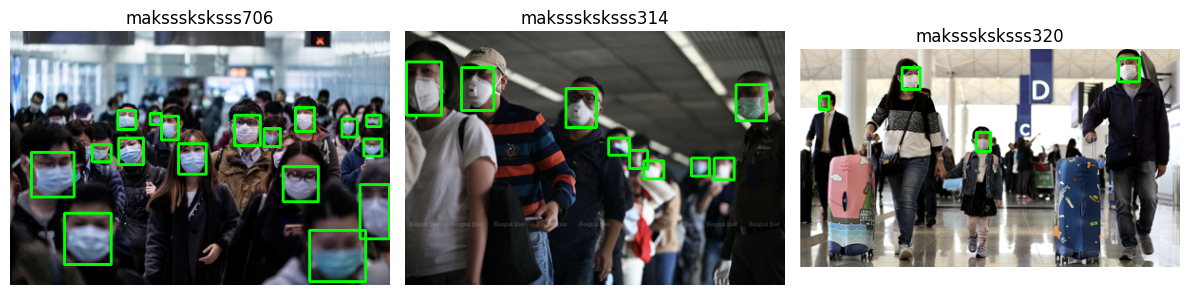

In [ ]:

import matplotlib.pyplot as plt

def draw_one(lblp, split="train"):
    stem = lblp.stem
    ip_png = OUT/"images"/split/(stem + ".png")
    ip_jpg = OUT/"images"/split/(stem + ".jpg")
    ip = ip_png if ip_png.exists() else ip_jpg
    im = cv2.imread(str(ip))
    H,W = im.shape[:2]
    for line in open(lblp):
        cid, cx, cy, w, h = map(float, line.strip().split())
        x1 = int((cx - w/2)*W); y1 = int((cy - h/2)*H)
        x2 = int((cx + w/2)*W); y2 = int((cy + h/2)*H)
        cv2.rectangle(im,(x1,y1),(x2,y2),(0,255,0),2)
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

lbls = sorted((OUT/"labels"/"train").glob("*.txt"))
fig, ax = plt.subplots(1,3, figsize=(12,4))
for i, p in enumerate(random.sample(lbls, 3)):
    ax[i].imshow(draw_one(p, "train")); ax[i].axis("off"); ax[i].set_title(p.stem)
plt.tight_layout(); plt.show()


In [ ]:
model_n = YOLO("yolov8n.pt")
DATA_YAML = (OUT/"face_mask.yaml").as_posix()

results = model_n.train(data=DATA_YAML,
                        imgsz=640,
                        epochs=15,
                        batch=32,
                        lr0=0.002,
                        weight_decay=5e-4,
                        mosaic=1.0, mixup=0.15, degrees=5, translate=0.1, scale=0.5, shear=2, fliplr=0.5,
                        patience=8,
                        project="runs_face_mask_fresh",
                        name="yolo_n",
                        pretrained=True)
N_BEST = Path("runs_face_mask_fresh/yolo_n/weights/best.pt")
print("Nano best exists:", N_BEST.exists(), N_BEST)


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data/face_mask_dn/face_mask.yaml, degrees=5, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=8, perspective=0.0, p

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


       1/15      5.65G      2.044      3.324      1.601        118        640: 100% ━━━━━━━━━━━━ 22/22 1.7it/s 13.1s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s2.3s
                   all         85        418    0.00422      0.156     0.0598     0.0307

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/15      5.65G      1.476       1.63       1.13        382        640: 68% ━━━━━━━━──── 15/22 2.4it/s 6.9s<2.9s

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


       2/15      5.65G      1.452      1.593      1.129         40        640: 100% ━━━━━━━━━━━━ 22/22 2.3it/s 9.5s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s2.0s
                   all         85        418      0.627     0.0217     0.0835     0.0529

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/15      5.65G      1.367       1.34      1.094        440        640: 77% ━━━━━━━━━─── 17/22 2.6it/s 7.4s<2.0s

...

      15/15      6.15G      1.062     0.7186     0.9721        114        640: 73% ━━━━━━━━╸─── 16/22 2.5it/s 6.4s<2.4s

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


      15/15      6.15G      1.064     0.7262     0.9675         53        640: 100% ━━━━━━━━━━━━ 22/22 2.7it/s 8.2s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.5it/s 0.6s1.5s
                   all         85        418      0.935      0.674      0.763      0.505

15 epochs completed in 0.042 hours.
Optimizer stripped from /kaggle/working/runs_face_mask_fresh/yolo_n/weights/last.pt, 6.2MB
Optimizer stripped from /kaggle/working/runs_face_mask_fresh/yolo_n/weights/best.pt, 6.2MB

Validating /kaggle/working/runs_face_mask_fresh/yolo_n/weights/best.pt...
Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [1]
Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:1 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         85        418      0.935      0.674      0.762      0.505
             with_mask         80        338      0.935      0.905      0.955      0.654
          without_mask         31         67      0.869      0.657      0.774      0.472
 mask_weared_incorrect         12         13          1      0.459      0.559      0.389
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/runs_face_mask_fresh/yolo_n
Nano best exists: True runs_face_mask_fresh/yolo_n/weights/best.pt


In [ ]:
model_s = YOLO("yolov8s.pt")
results_s = model_s.train(data=DATA_YAML,
                          imgsz=640,
                          epochs=60,
                          batch=16,
                          lr0=0.002,
                          lrf=0.01,
                          weight_decay=5e-4,
                          mosaic=1.0, mixup=0.15, degrees=5, translate=0.1, scale=0.5, shear=2, fliplr=0.5,
                          patience=15,
                          project="runs_face_mask_fresh",
                          name="yolo_s",
                          pretrained=True)
S_BEST = Path("runs_face_mask_fresh/yolo_s/weights/best.pt")
print("Small best exists:", S_BEST.exists(), S_BEST)


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data/face_mask_dn/face_mask.yaml, degrees=5, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, p

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


       1/60      4.57G      1.791       2.16      1.486         92        640: 100% ━━━━━━━━━━━━ 43/43 3.3it/s 13.1s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.8it/s 0.8s0.6s
                   all         85        418      0.517      0.444      0.498      0.298

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      4.93G      1.394      1.125      1.177        128        640: 67% ━━━━━━━━──── 29/43 3.8it/s 7.9s<3.7s

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


       2/60      4.93G      1.357      1.093      1.171         95        640: 100% ━━━━━━━━━━━━ 43/43 3.8it/s 11.2s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.0it/s 0.7s0.5s
                   all         85        418      0.833       0.46      0.486      0.302

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      4.93G      1.261     0.9528      1.153        151        640: 33% ━━━╸──────── 14/43 3.9it/s 3.9s<7.4s

...

      59/60      5.72G       0.85     0.3898     0.9222         27        640: 100% ━━━━━━━━━━━━ 43/43 3.8it/s 11.4s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.9it/s 0.6s0.5s
                   all         85        418      0.938      0.797      0.863        0.6

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      60/60      5.72G      0.853     0.3882     0.9203         56        640: 51% ━━━━━━────── 22/43 3.8it/s 6.1s<5.6s

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


      60/60      5.72G     0.8446     0.3817     0.9236         49        640: 100% ━━━━━━━━━━━━ 43/43 3.8it/s 11.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.7it/s 0.6s0.5s
                   all         85        418      0.943      0.801      0.862      0.603

60 epochs completed in 0.215 hours.
Optimizer stripped from /kaggle/working/runs_face_mask_fresh/yolo_s/weights/last.pt, 22.5MB
Optimizer stripped from /kaggle/working/runs_face_mask_fresh/yolo_s/weights/best.pt, 22.5MB

Validating /kaggle/working/runs_face_mask_fresh/yolo_s/weights/best.pt...
Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:1 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.5it/s 1.2s0.5s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         85        418      0.949      0.787      0.864      0.604
             with_mask         80        338      0.936       0.91       0.97      0.711
          without_mask         31         67      0.911      0.767      0.873      0.548
 mask_weared_incorrect         12         13          1      0.683      0.748      0.554
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs_face_mask_fresh/yolo_s
Small best exists: True runs_face_mask_fresh/yolo_s/weights/best.pt


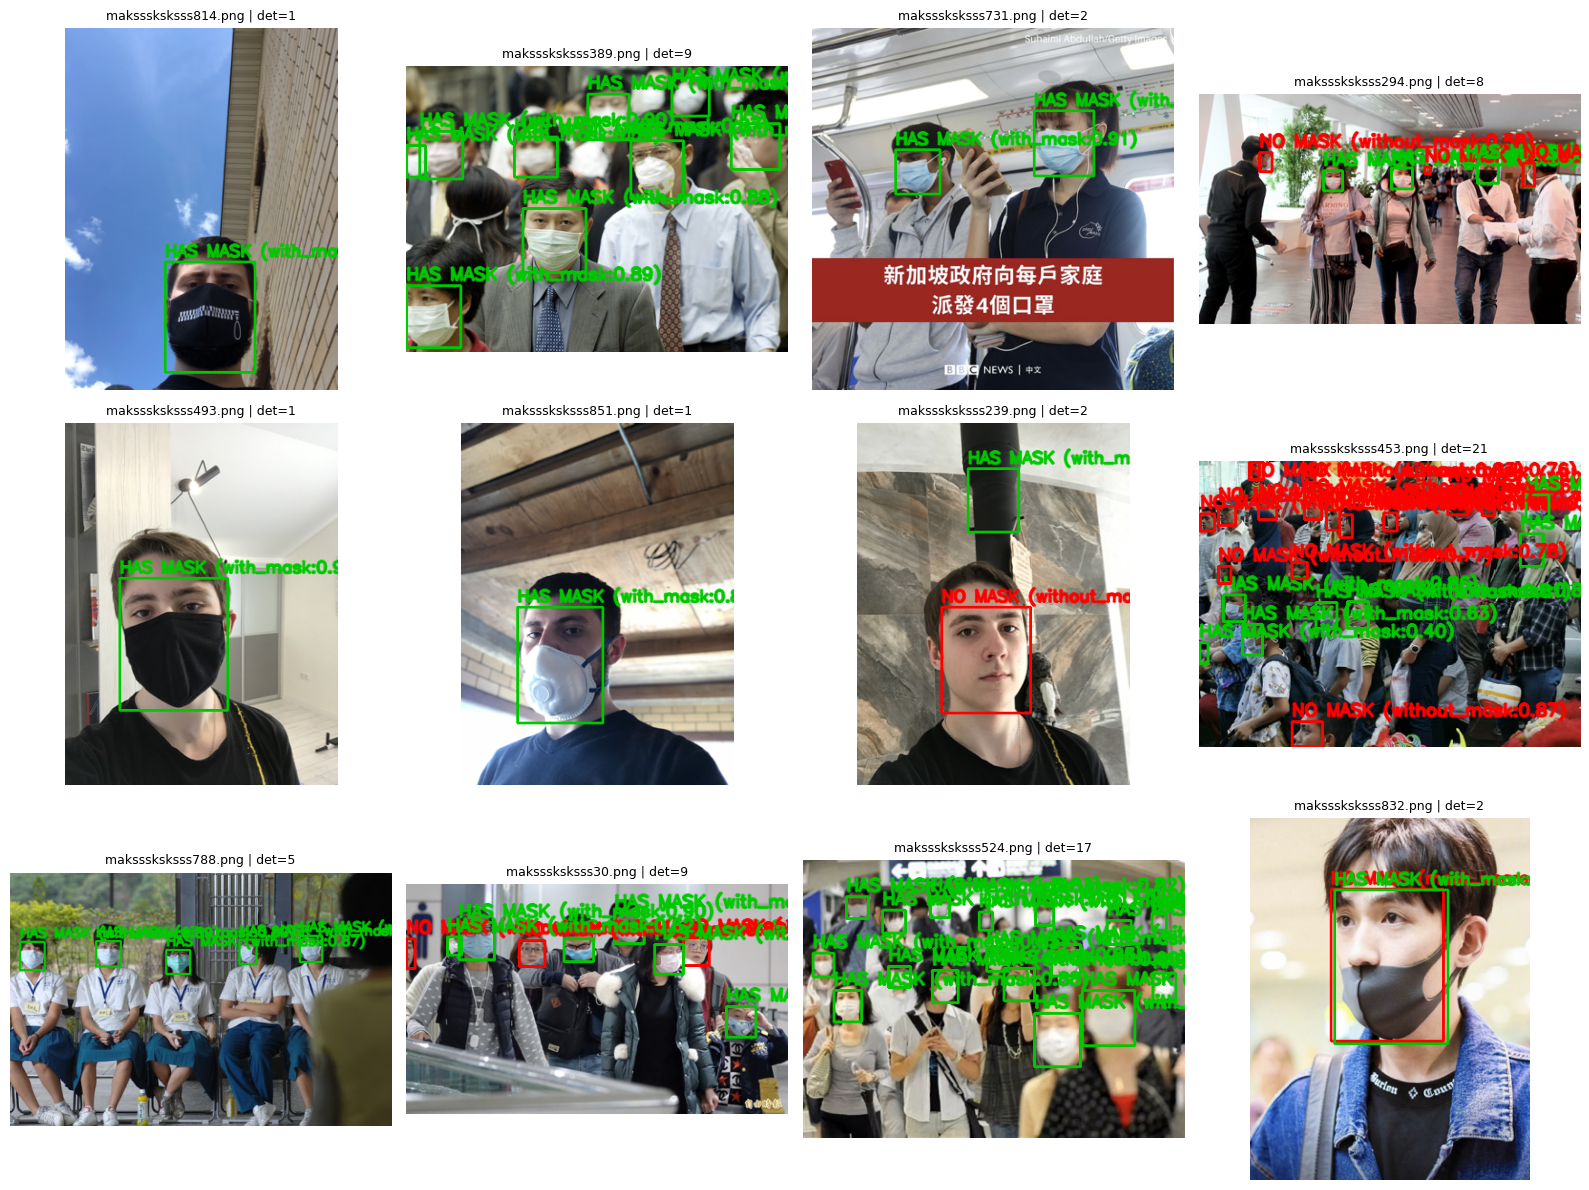

In [ ]:
import matplotlib.pyplot as plt

BEST = S_BEST if S_BEST.exists() else N_BEST
model = YOLO(BEST.as_posix())
CLASSES = ["with_mask","without_mask","mask_weared_incorrect"]

def tag_color(cls_id):
    name = CLASSES[int(cls_id)]
    return ("HAS MASK",(0,200,0)) if name=="with_mask" else ("NO MASK",(0,0,255)), name

def run_and_draw(ip, imgsz=960, conf=0.15, iou=0.6):
    im = cv2.imread(str(ip))
    r = model.predict(source=im, imgsz=imgsz, conf=conf, iou=iou, verbose=False)[0]
    vis = im.copy()
    n=0
    if r.boxes is not None and len(r.boxes)>0:
        for b,c,s in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy(), r.boxes.conf.cpu().numpy()):
            n+=1
            x1,y1,x2,y2 = map(int,b)
            (tag,color), name = tag_color(c)
            cv2.rectangle(vis,(x1,y1),(x2,y2), color, 2)
            cv2.putText(vis, f"{tag} ({name}:{s:.2f})", (x1,max(15,y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
    else:
        cv2.putText(vis, "NO DETECTIONS", (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 2)
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), n

val_imgs = sorted((OUT/"images"/"val").glob("*.*"))
samples = random.sample(val_imgs, min(12, len(val_imgs)))
cols=4; rows=int(np.ceil(len(samples)/cols))
plt.figure(figsize=(4*cols,4*rows))
for i, ip in enumerate(samples, 1):
    rgb, n = run_and_draw(ip, imgsz=960, conf=0.15, iou=0.6)
    plt.subplot(rows, cols, i); plt.imshow(rgb); plt.axis("off"); plt.title(f"{ip.name} | det={n}", fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
OUT_VIS = ROOT/"preds_vis_val"
OUT_VIS.mkdir(parents=True, exist_ok=True)

saved=0
for ip in val_imgs:
    rgb, n = run_and_draw(ip, imgsz=960, conf=0.15, iou=0.6)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(OUT_VIS/ip.name), bgr); saved+=1
print("Saved annotated images to:", OUT_VIS, "count:", saved)


Saved annotated images to: /kaggle/working/preds_vis_val count: 85


In [46]:
m = YOLO(BEST.as_posix())
onnx = m.export(format="onnx", dynamic=True, opset=12)
print("Exported ONNX:", onnx)


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs_face_mask_fresh/yolo_s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)

ONNX: starting export with onnx 1.18.0 opset 12...
ONNX: slimming with onnxslim 0.1.70...
ONNX: export success ✅ 5.1s, saved as 'runs_face_mask_fresh/yolo_s/weights/best.onnx' (42.8 MB)

Export complete (5.8s)
Results saved to /kaggle/working/runs_face_mask_fresh/yolo_s/weights
Predict:         yolo predict task=detect model=runs_face_mask_fresh/yolo_s/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs_face_mask_fresh/yolo_s/weights/best.onnx imgsz=640 data=/kaggle/working/data/face_mask_dn/face_mask.yaml  
Visualize:       https://netron.app
Exported ONNX: runs_face_mask_fresh/yolo_s/weights/best.onnx


In [51]:
!pip -q install timm torchmetrics

import os, time, random
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tvm
from PIL import Image
import timm
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ROOT = Path("/kaggle/working")
DATA_ROOT = ROOT / "data" / "face_mask_dn"
assert (DATA_ROOT/"images/train").exists(), "Expected YOLO dataset at /kaggle/working/data/face_mask_dn"
print("Device:", DEVICE)


Device: cuda


In [52]:
WITH_MASK_ID = 0
IMAGENET_MEAN = [0.485,0.456,0.406]
IMAGENET_STD  = [0.229,0.224,0.225]

def load_yolo(lbl_path: Path):
    if not lbl_path.exists(): return []
    out=[]
    for ln in open(lbl_path):
        ln=ln.strip()
        if not ln: continue
        cls,cx,cy,w,h = map(float, ln.split())
        out.append((int(cls),cx,cy,w,h))
    return out

def crop_from_box(im: Image.Image, cx,cy,w,h):
    W,H = im.size
    x1 = int((cx - w/2)*W); y1 = int((cy - h/2)*H)
    x2 = int((cx + w/2)*W); y2 = int((cy + h/2)*H)
    x1,y1 = max(0,x1), max(0,y1)
    x2,y2 = min(W-1,x2), min(H-1,y2)
    if x2<=x1 or y2<=y1:
        s=min(W,H); return im.crop(((W-s)//2,(H-s)//2,(W+s)//2,(H+s)//2))
    return im.crop((x1,y1,x2,y2))

class FaceCropBin(Dataset):
    def __init__(self, split="train", img_size=224, max_crops_per_image=1, augment=True):
        self.img_dir = DATA_ROOT/"images"/split
        self.lbl_dir = DATA_ROOT/"labels"/split
        self.items = []
        for ip in sorted(self.img_dir.glob("*.*")):
            lp = self.lbl_dir/(ip.stem + ".txt")
            if lp.exists():
                self.items.append((ip, lp))
        aug_list=[]
        if augment and split=="train":
            aug_list += [T.RandomResizedCrop(img_size, scale=(0.8,1.0)),
                         T.RandomHorizontalFlip(),
                         T.ColorJitter(0.2,0.2,0.2,0.1)]
        else:
            aug_list += [T.Resize((img_size,img_size))]
        aug_list += [T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
        self.tf = T.Compose(aug_list)
        self.max_crops = max_crops_per_image

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        ip, lp = self.items[idx]
        im = Image.open(ip).convert("RGB")
        labels = load_yolo(lp)
        if self.max_crops and len(labels)>0:
            labels = random.sample(labels, min(self.max_crops, len(labels)))
        if len(labels)==0:
            crop = im; y = 0
        else:
            cls,cx,cy,w,h = random.choice(labels)
            crop = crop_from_box(im,cx,cy,w,h)
            y = 1 if cls==WITH_MASK_ID else 0
        x = self.tf(crop)
        return x, torch.tensor(y, dtype=torch.long)

def make_balanced_sampler(ds: Dataset, num_classes=2):
    counts=[0]*num_classes; labels=[]
    for i in range(len(ds)):
        _,y = ds[i]; y=int(y); labels.append(y); counts[y]+=1
    total=float(sum(counts))
    weights=[0]*num_classes
    for c in range(num_classes): weights[c]= total / max(1,counts[c])
    w=[weights[y] for y in labels]
    return WeightedRandomSampler(w, num_samples=len(w), replacement=True)

train_ds = FaceCropBin("train", 224, 1, True)
val_ds   = FaceCropBin("val",   224, 1, False)
test_ds  = FaceCropBin("test",  224, 1, False)

train_loader = DataLoader(train_ds, batch_size=64, sampler=make_balanced_sampler(train_ds), num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Splits -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))


Splits -> train: 682 val: 85 test: 86


In [ ]:
# Deepmasknet (compact CNN)
class DeepMaskNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def blk(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, 1, 1, bias=False),
                                 nn.BatchNorm2d(cout),
                                 nn.LeakyReLU(0.01, inplace=True))
        self.stem = nn.Sequential(
            nn.Conv2d(3,128,3,4,0,bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.01,True),
            nn.MaxPool2d(3,2)
        )
        self.body = nn.Sequential(
            blk(128,512), nn.MaxPool2d(3,2),
            blk(512,384), nn.MaxPool2d(3,2),
            blk(384,256), blk(256,256), blk(256,256),
            nn.MaxPool2d(3,2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*3*3, 512), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self,x): return self.head(self.body(self.stem(x)))

# Builders for listed models; all output 2 classes
def build_model(name: str, num_classes=2):
    name_l = name.lower()
    if name_l == "deepmasknet":
        return DeepMaskNet(num_classes)
    elif name_l == "googlenet":
        m = tvm.googlenet(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "squeezenet":
        m = tvm.squeezenet1_1(weights="IMAGENET1K_V1"); m.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1); return m
    elif name_l == "densenet201":
        m = tvm.densenet201(weights="IMAGENET1K_V1"); m.classifier = nn.Linear(m.classifier.in_features, num_classes); return m
    elif name_l == "shufflenet":
        m = tvm.shufflenet_v2_x1_0(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "resnet18":
        m = tvm.resnet18(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "mobilenetv2":
        m = tvm.mobilenet_v2(weights="IMAGENET1K_V2"); m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes); return m
    elif name_l == "inceptionresnetv2":
        m = timm.create_model("inception_resnet_v2", pretrained=True, num_classes=num_classes); return m
    elif name_l == "darknet19":
        m = timm.create_model("darknet53", pretrained=True, num_classes=num_classes)  # closest available
        return m
    elif name_l == "darknet53":
        m = timm.create_model("darknet53", pretrained=True, num_classes=num_classes); return m
    else:
        raise ValueError(f"Unknown model: {name}")


In [ ]:
class DeepMaskNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def blk(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, 1, 1, bias=False),
                nn.BatchNorm2d(cout),
                nn.LeakyReLU(0.01, inplace=True)
            )
        self.stem = nn.Sequential(
            nn.Conv2d(3,128,3,4,0,bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.01,True),
            nn.MaxPool2d(3,2)
        )
        self.body = nn.Sequential(
            blk(128,512), nn.MaxPool2d(3,2),
            blk(512,384), nn.MaxPool2d(3,2),
            blk(384,256), blk(256,256), blk(256,256),
            nn.MaxPool2d(3,2),
        )
        self.tail_pool = nn.AdaptiveAvgPool2d((3,3))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*3*3, 512), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.LeakyReLU(0.01,True), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.body(x)
        x = self.tail_pool(x)  
        x = self.head(x)
        return x

def build_model(name: str, num_classes=2):
    name_l = name.lower()
    if name_l == "deepmasknet":
        return DeepMaskNet(num_classes)
    elif name_l == "googlenet":
        m = tvm.googlenet(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "squeezenet":
        m = tvm.squeezenet1_1(weights="IMAGENET1K_V1"); m.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1); return m
    elif name_l == "densenet201":
        m = tvm.densenet201(weights="IMAGENET1K_V1"); m.classifier = nn.Linear(m.classifier.in_features, num_classes); return m
    elif name_l == "shufflenet":
        m = tvm.shufflenet_v2_x1_0(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "resnet18":
        m = tvm.resnet18(weights="IMAGENET1K_V1"); m.fc = nn.Linear(m.fc.in_features, num_classes); return m
    elif name_l == "mobilenetv2":
        m = tvm.mobilenet_v2(weights="IMAGENET1K_V2"); m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes); return m
    elif name_l == "inceptionresnetv2":
        m = timm.create_model("inception_resnet_v2", pretrained=True, num_classes=num_classes); return m
    elif name_l == "darknet19":
        m = timm.create_model("darknet53", pretrained=True, num_classes=num_classes); return m
    elif name_l == "darknet53":
        m = timm.create_model("darknet53", pretrained=True, num_classes=num_classes); return m
    else:
        raise ValueError(f"Unknown model: {name}")


In [ ]:
models = [
    "Deepmasknet",
    "GoogleNet",
    "Squeezenet",
    "Densenet201",
    "Shufflenet",
    "Resnet18",
    "Mobilenetv2",
    "Inceptionresnetv2",
    "Darknet19",
    "Darknet53",
]

EPOCHS=8       
LR=1e-3
results=[]

for name in models:
    print(f"\n==== {name} ====")
    model = build_model(name, num_classes=2).to(DEVICE)
    
    optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_f1=0.0; best_state=None
    for epoch in range(1, EPOCHS+1):
        tr_loss = train_one_epoch(model, train_loader, optim, criterion)
        va_acc, va_prec, va_rec, va_f1 = eval_metrics(model, val_loader)
        print(f"Epoch {epoch:02d} | train_loss {tr_loss:.4f} | val Acc {va_acc:.4f} P {va_prec:.4f} R {va_rec:.4f} F1 {va_f1:.4f}")
        if va_f1 > best_f1:
            best_f1 = va_f1
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})

    te_acc, te_prec, te_rec, te_f1 = eval_metrics(model, test_loader)
    results.append([name, te_acc, te_prec, te_rec, te_f1])
    print(f"Test -> Acc {te_acc:.4f} | P {te_prec:.4f} | R {te_rec:.4f} | F1 {te_f1:.4f}")



==== Deepmasknet ====
Epoch 01 | train_loss 0.6416 | val Acc 0.7882 P 0.7882 R 1.0000 F1 0.8816
Epoch 02 | train_loss 0.5344 | val Acc 0.8941 P 0.9429 R 0.9296 F1 0.9362
Epoch 03 | train_loss 0.4571 | val Acc 0.9176 P 0.9701 R 0.9286 F1 0.9489
Epoch 04 | train_loss 0.3557 | val Acc 0.9059 P 0.9200 R 0.9718 F1 0.9452
Epoch 05 | train_loss 0.3853 | val Acc 0.9176 P 0.9286 R 0.9701 F1 0.9489
Epoch 06 | train_loss 0.2617 | val Acc 0.9294 P 0.9714 R 0.9444 F1 0.9577
Epoch 07 | train_loss 0.2564 | val Acc 0.9647 P 0.9726 R 0.9861 F1 0.9793
Epoch 08 | train_loss 0.2556 | val Acc 0.9765 P 1.0000 R 0.9710 F1 0.9853
Test -> Acc 0.9186 | P 0.9559 | R 0.9420 | F1 0.9489

==== GoogleNet ====


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 155MB/s] 


Epoch 01 | train_loss 0.2581 | val Acc 0.8588 P 0.8571 R 0.9851 F1 0.9167
Epoch 02 | train_loss 0.1421 | val Acc 0.9294 P 0.9701 R 0.9420 F1 0.9559
Epoch 03 | train_loss 0.0769 | val Acc 0.9059 P 1.0000 R 0.8824 F1 0.9375
Epoch 04 | train_loss 0.1120 | val Acc 0.9647 P 0.9589 R 1.0000 F1 0.9790
Epoch 05 | train_loss 0.0907 | val Acc 0.9882 P 0.9865 R 1.0000 F1 0.9932
Epoch 06 | train_loss 0.1120 | val Acc 0.9412 P 0.9589 R 0.9722 F1 0.9655
Epoch 07 | train_loss 0.0934 | val Acc 0.9294 P 0.9412 R 0.9697 F1 0.9552
Epoch 08 | train_loss 0.0845 | val Acc 0.9647 P 1.0000 R 0.9589 F1 0.9790


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


Test -> Acc 0.9419 | P 1.0000 | R 0.9275 | F1 0.9624

==== Squeezenet ====


...

Epoch 01 | train_loss 0.3368 | val Acc 0.8471 P 0.9825 R 0.8235 F1 0.8960
Epoch 02 | train_loss 0.1762 | val Acc 0.8118 P 1.0000 R 0.7714 F1 0.8710
Epoch 03 | train_loss 0.1232 | val Acc 0.9176 P 0.9189 R 0.9855 F1 0.9510
Epoch 04 | train_loss 0.0706 | val Acc 0.9412 P 0.9688 R 0.9538 F1 0.9612
Epoch 05 | train_loss 0.0450 | val Acc 0.9412 P 0.9324 R 1.0000 F1 0.9650
Epoch 06 | train_loss 0.1159 | val Acc 0.9529 P 0.9552 R 0.9846 F1 0.9697
Epoch 07 | train_loss 0.0905 | val Acc 0.9529 P 1.0000 R 0.9412 F1 0.9697
Epoch 08 | train_loss 0.0456 | val Acc 0.9529 P 0.9851 R 0.9565 F1 0.9706
Test -> Acc 0.9535 | P 0.9714 | R 0.9714 | F1 0.9714

==== Inceptionresnetv2 ====


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Epoch 01 | train_loss 0.3532 | val Acc 0.8824 P 0.9375 R 0.9091 F1 0.9231
Epoch 02 | train_loss 0.1965 | val Acc 0.8588 P 0.9831 R 0.8406 F1 0.9062
Epoch 03 | train_loss 0.0765 | val Acc 0.9059 P 0.9692 R 0.9130 F1 0.9403
Epoch 04 | train_loss 0.0972 | val Acc 0.9529 P 0.9857 R 0.9583 F1 0.9718
Epoch 05 | train_loss 0.0618 | val Acc 0.9529 P 0.9710 R 0.9710 F1 0.9710
Epoch 06 | train_loss 0.1232 | val Acc 0.9882 P 1.0000 R 0.9861 F1 0.9930
Epoch 07 | train_loss 0.0784 | val Acc 0.9529 P 1.0000 R 0.9429 F1 0.9706
Epoch 08 | train_loss 0.0705 | val Acc 0.9765 P 1.0000 R 0.9710 F1 0.9853
Test -> Acc 0.9651 | P 0.9859 | R 0.9722 | F1 0.9790

==== Darknet19 ====


model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Epoch 01 | train_loss 0.3845 | val Acc 0.8353 P 0.8395 R 0.9855 F1 0.9067
Epoch 02 | train_loss 0.2165 | val Acc 0.9294 P 0.9846 R 0.9275 F1 0.9552
Epoch 03 | train_loss 0.1570 | val Acc 0.9059 P 0.9710 R 0.9178 F1 0.9437
Epoch 04 | train_loss 0.1569 | val Acc 0.8941 P 0.8875 R 1.0000 F1 0.9404
Epoch 05 | train_loss 0.1125 | val Acc 0.9294 P 0.9559 R 0.9559 F1 0.9559
Epoch 06 | train_loss 0.1501 | val Acc 0.8824 P 0.8904 R 0.9701 F1 0.9286
Epoch 07 | train_loss 0.1630 | val Acc 0.8471 P 0.9355 R 0.8657 F1 0.8992
Epoch 08 | train_loss 0.1206 | val Acc 0.9294 P 1.0000 R 0.9143 F1 0.9552
Test -> Acc 0.9651 | P 0.9859 | R 0.9722 | F1 0.9790

==== Darknet53 ====
Epoch 01 | train_loss 0.3223 | val Acc 0.8941 P 0.8831 R 1.0000 F1 0.9379
Epoch 02 | train_loss 0.1970 | val Acc 0.8235 P 0.8193 R 1.0000 F1 0.9007
Epoch 03 | train_loss 0.1338 | val Acc 0.8941 P 0.9841 R 0.8857 F1 0.9323
Epoch 04 | train_loss 0.1587 | val Acc 0.9176 P 0.9315 R 0.9714 F1 0.9510
Epoch 05 | train_loss 0.1336 | val Acc

In [59]:
import pandas as pd
df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
display(df.sort_values("F1", ascending=False))

csv_path = ROOT/"benchmark_results_mask_binary.csv"
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)


,Model,Accuracy,Precision,Recall,F1
4,Shufflenet,0.976744,1.000000,0.971429,0.985507
5,Resnet18,0.976744,1.000000,0.971429,0.985507
8,Darknet19,0.965116,0.985915,0.972222,0.979021
7,Inceptionresnetv2,0.965116,0.985915,0.972222,0.979021
6,Mobilenetv2,0.953488,0.971429,0.971429,0.971429
3,Densenet201,0.953488,0.971014,0.971014,0.971014
1,GoogleNet,0.941860,1.000000,0.927536,0.962406
9,Darknet53,0.930233,1.000000,0.917808,0.957143
0,Deepmasknet,0.918605,0.955882,0.942029,0.948905
2,Squeezenet,0.813953,0.813953,1.000000,0.897436


Saved: /kaggle/working/benchmark_results_mask_binary.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/kaggle/working")
csv_path = ROOT/"benchmark_results_mask_binary.csv"
df = pd.read_csv(csv_path)

order = ["Deepmasknet","GoogleNet","Squeezenet","Densenet201","Shufflenet",
         "Resnet18","Mobilenetv2","Inceptionresnetv2","Darknet19","Darknet53"]
df["Model"] = pd.Categorical(df["Model"], categories=order, ordered=True)
df = df.sort_values("Model")
display(df)


,Model,Accuracy,Precision,Recall,F1
0,Deepmasknet,0.918605,0.955882,0.942029,0.948905
1,GoogleNet,0.941860,1.000000,0.927536,0.962406
2,Squeezenet,0.813953,0.813953,1.000000,0.897436
3,Densenet201,0.953488,0.971014,0.971014,0.971014
4,Shufflenet,0.976744,1.000000,0.971429,0.985507
5,Resnet18,0.976744,1.000000,0.971429,0.985507
6,Mobilenetv2,0.953488,0.971429,0.971429,0.971429
7,Inceptionresnetv2,0.965116,0.985915,0.972222,0.979021
8,Darknet19,0.965116,0.985915,0.972222,0.979021
9,Darknet53,0.930233,1.000000,0.917808,0.957143


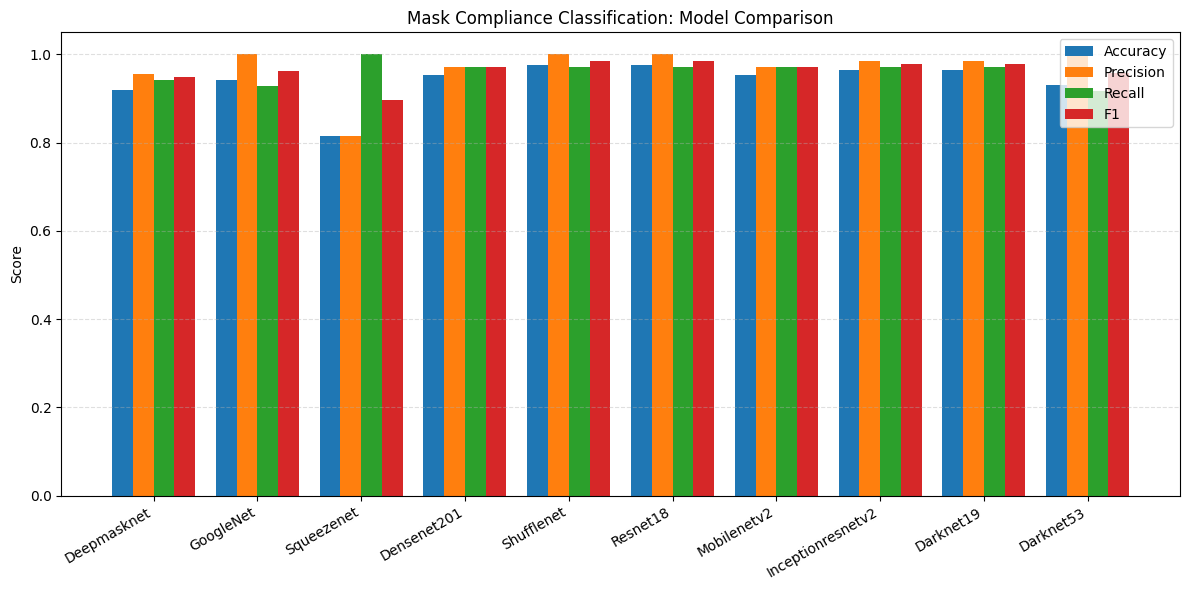

In [61]:
plt.figure(figsize=(12,6))
x = np.arange(len(df))
w = 0.2

plt.bar(x - 1.5*w, df["Accuracy"],  width=w, label="Accuracy")
plt.bar(x - 0.5*w, df["Precision"], width=w, label="Precision")
plt.bar(x + 0.5*w, df["Recall"],    width=w, label="Recall")
plt.bar(x + 1.5*w, df["F1"],        width=w, label="F1")

plt.xticks(x, df["Model"], rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Mask Compliance Classification: Model Comparison")
plt.legend()
plt.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


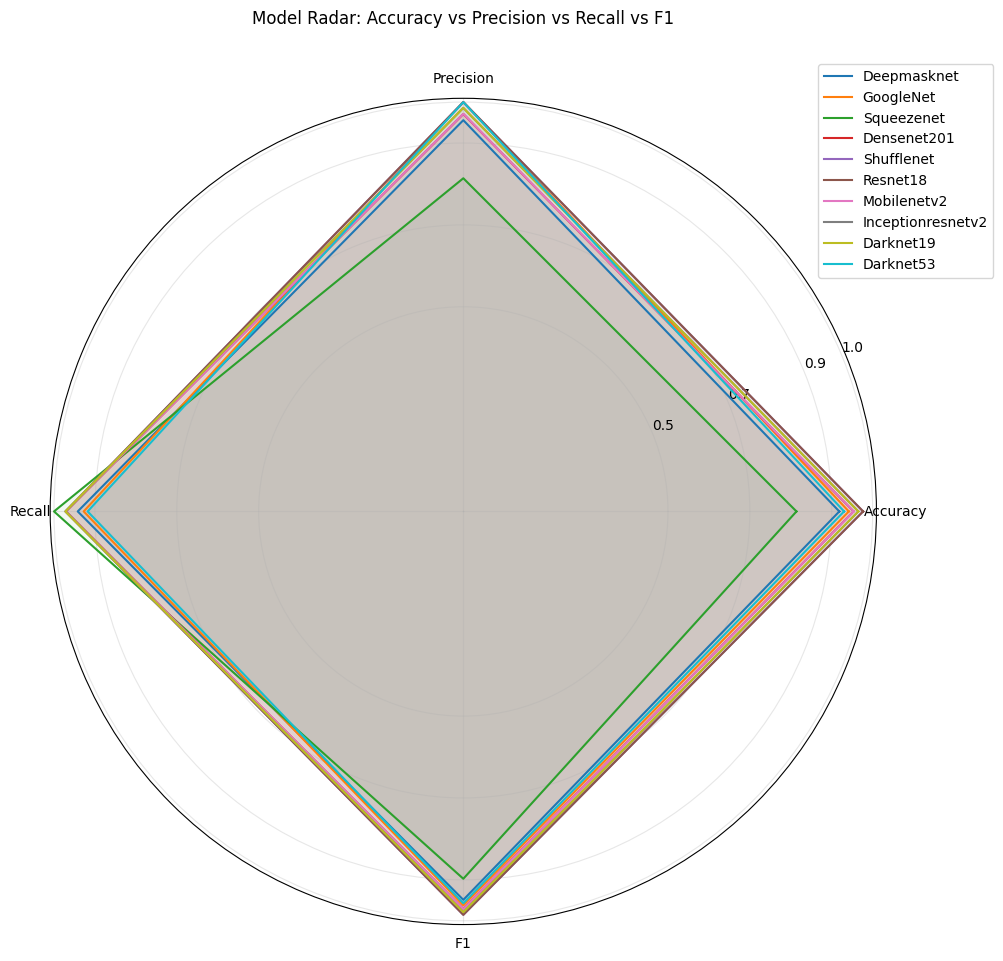

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy","Precision","Recall","F1"]
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1] 

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for _, row in df.iterrows():
    vals = row[metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=1.5, label=row["Model"])
    ax.fill(angles, vals, alpha=0.06)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_yticks([0.5, 0.7, 0.9, 1.0])
ax.set_yticklabels(["0.5","0.7","0.9","1.0"])
ax.set_title("Model Radar: Accuracy vs Precision vs Recall vs F1", y=1.08)
ax.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.15, 1.05))
plt.tight_layout()
plt.show()


In [63]:
from IPython.display import display, HTML

def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: #d0f0c0' if v else '' for v in is_max]

styled = (df.style
            .format({"Accuracy":"{:.3f}","Precision":"{:.3f}","Recall":"{:.3f}","F1":"{:.3f}"})
            .apply(highlight_best, subset=["Accuracy","Precision","Recall","F1"]))
display(styled)


,Model,Accuracy,Precision,Recall,F1
0,Deepmasknet,0.919,0.956,0.942,0.949
1,GoogleNet,0.942,1.000,0.928,0.962
2,Squeezenet,0.814,0.814,1.000,0.897
3,Densenet201,0.953,0.971,0.971,0.971
4,Shufflenet,0.977,1.000,0.971,0.986
5,Resnet18,0.977,1.000,0.971,0.986
6,Mobilenetv2,0.953,0.971,0.971,0.971
7,Inceptionresnetv2,0.965,0.986,0.972,0.979
8,Darknet19,0.965,0.986,0.972,0.979
9,Darknet53,0.930,1.000,0.918,0.957


In [ ]:

bar_path   = ROOT/"model_comparison_bars.png"
radar_path = ROOT/"model_comparison_radar.png"


plt.figure(figsize=(12,6))
x = np.arange(len(df)); w=0.2
plt.bar(x - 1.5*w, df["Accuracy"],  width=w, label="Accuracy")
plt.bar(x - 0.5*w, df["Precision"], width=w, label="Precision")
plt.bar(x + 0.5*w, df["Recall"],    width=w, label="Recall")
plt.bar(x + 1.5*w, df["F1"],        width=w, label="F1")
plt.xticks(x, df["Model"], rotation=30, ha="right")
plt.ylim(0, 1.05); plt.ylabel("Score")
plt.title("Mask Compliance Classification: Model Comparison")
plt.legend(); plt.grid(axis="y", ls="--", alpha=0.4); plt.tight_layout()
plt.savefig(bar_path, dpi=200); plt.close()
print("Saved:", bar_path)


metrics = ["Accuracy","Precision","Recall","F1"]
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
plt.figure(figsize=(10,10)); ax = plt.subplot(111, polar=True)
for _, row in df.iterrows():
    vals = row[metrics].tolist(); vals += vals[:1]
    ax.plot(angles, vals, linewidth=1.5, label=row["Model"])
    ax.fill(angles, vals, alpha=0.06)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics)
ax.set_yticks([0.5, 0.7, 0.9, 1.0]); ax.set_yticklabels(["0.5","0.7","0.9","1.0"])
ax.set_title("Model Radar: Accuracy vs Precision vs Recall vs F1", y=1.08)
ax.grid(True, alpha=0.3); plt.legend(bbox_to_anchor=(1.15, 1.05)); plt.tight_layout()
plt.savefig(radar_path, dpi=200); plt.close()
print("Saved:", radar_path)


Saved: /kaggle/working/model_comparison_bars.png
Saved: /kaggle/working/model_comparison_radar.png


In [ ]:
import torch, torch.nn.functional as F
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


models = [
    "Deepmasknet",
    "GoogleNet",
    "Squeezenet",
    "Densenet201",
    "Shufflenet",
    "Resnet18",
    "Mobilenetv2",
    "Inceptionresnetv2",
    "Darknet19",
    "Darknet53",
]


weights_dir = Path("/kaggle/working/saved_bin_checkpoints")  
weights_map = {m: (weights_dir/f"{m}.pt") for m in models}

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    TP = int(np.sum((y_true==1) & (y_pred==1)))
    FP = int(np.sum((y_true==0) & (y_pred==1)))
    FN = int(np.sum((y_true==1) & (y_pred==0)))
    TN = int(np.sum((y_true==0) & (y_pred==0)))
    return TP, FP, FN, TN

conf_by_model = {}

for name in models:
    model = build_model(name, num_classes=2).to(DEVICE)
    
    if weights_map.get(name) and weights_map[name].exists():
        state = torch.load(weights_map[name], map_location=DEVICE)
        model.load_state_dict(state)

    model.eval()
    y_true=[]; y_pred=[]
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            pred = (probs >= 0.5).astype(int)
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(pred.tolist())

    TP, FP, FN, TN = confusion_counts(y_true, y_pred)
    conf_by_model[name] = dict(TP=TP, FP=FP, FN=FN, TN=TN)

conf_by_model


{'Deepmasknet': {'TP': 0, 'FP': 0, 'FN': 69, 'TN': 17},
 'GoogleNet': {'TP': 38, 'FP': 10, 'FN': 33, 'TN': 5},
 'Squeezenet': {'TP': 70, 'FP': 10, 'FN': 2, 'TN': 4},
 'Densenet201': {'TP': 15, 'FP': 11, 'FN': 56, 'TN': 4},
 'Shufflenet': {'TP': 0, 'FP': 0, 'FN': 71, 'TN': 15},
 'Resnet18': {'TP': 20, 'FP': 7, 'FN': 46, 'TN': 13},
 'Mobilenetv2': {'TP': 53, 'FP': 16, 'FN': 15, 'TN': 2},
 'Inceptionresnetv2': {'TP': 5, 'FP': 0, 'FN': 66, 'TN': 15},
 'Darknet19': {'TP': 25, 'FP': 2, 'FN': 45, 'TN': 14},
 'Darknet53': {'TP': 57, 'FP': 12, 'FN': 15, 'TN': 2}}

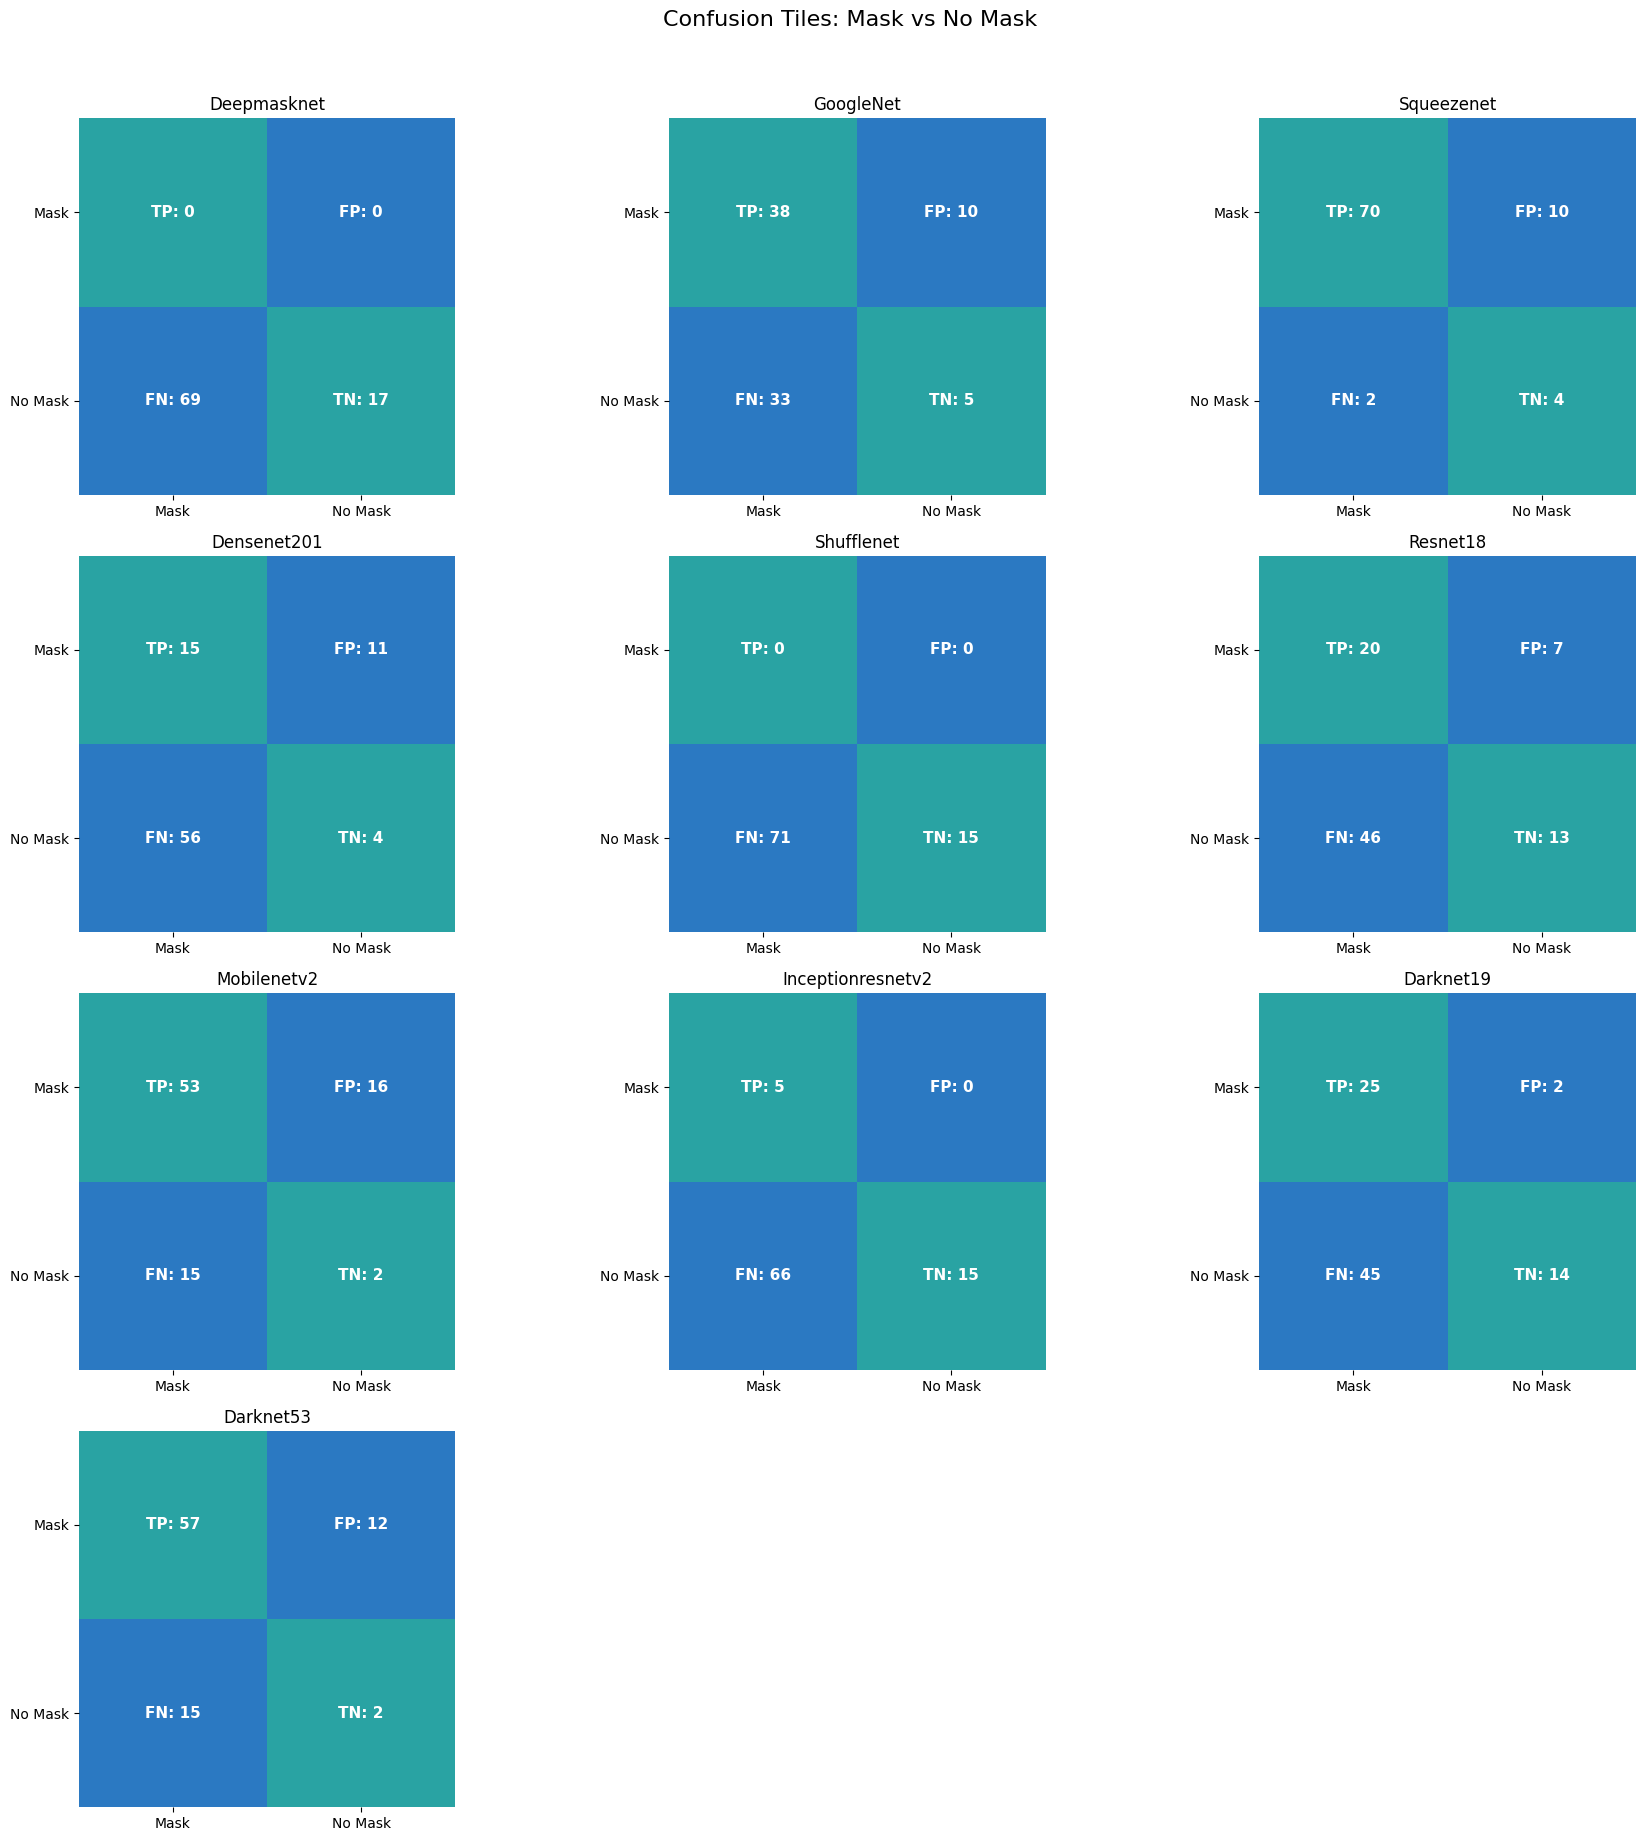

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_quad(ax, title, TP, FP, FN, TN):
    
    ax.add_patch(patches.Rectangle((0,1), 1,1, facecolor="#29a3a3"))  # TP
    ax.add_patch(patches.Rectangle((1,1), 1,1, facecolor="#2b79c2"))  # FP
    ax.add_patch(patches.Rectangle((0,0), 1,1, facecolor="#2b79c2"))  # FN
    ax.add_patch(patches.Rectangle((1,0), 1,1, facecolor="#29a3a3"))  # TN
    ax.text(0.5,1.5, f"TP: {TP}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
    ax.text(1.5,1.5, f"FP: {FP}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
    ax.text(0.5,0.5, f"FN: {FN}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
    ax.text(1.5,0.5, f"TN: {TN}", va="center", ha="center", color="white", fontsize=11, fontweight="bold")
    ax.set_xticks([0.5,1.5]); ax.set_xticklabels(["Mask","No Mask"])
    ax.set_yticks([0.5,1.5]); ax.set_yticklabels(["No Mask","Mask"])
    ax.set_xlim(0,2); ax.set_ylim(0,2); ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)


names = list(conf_by_model.keys())
cols = 3
rows = int(np.ceil(len(names)/cols))
plt.figure(figsize=(6*cols, 4.5*rows))
for i, name in enumerate(names, 1):
    ax = plt.subplot(rows, cols, i)
    c = conf_by_model[name]
    draw_quad(ax, name, c["TP"], c["FP"], c["FN"], c["TN"])
plt.suptitle("Confusion Tiles: Mask vs No Mask", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
